<a href="https://colab.research.google.com/github/harifaly/EDA_TRAINING/blob/main/Titanic_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [309]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [310]:
print("Shape :", df.shape)

Shape : (891, 12)


In [311]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Valeur manquant

In [312]:
# _____analyse de valeur manquant_______
manquants=df.isnull().sum()
print(manquants)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


<Axes: >

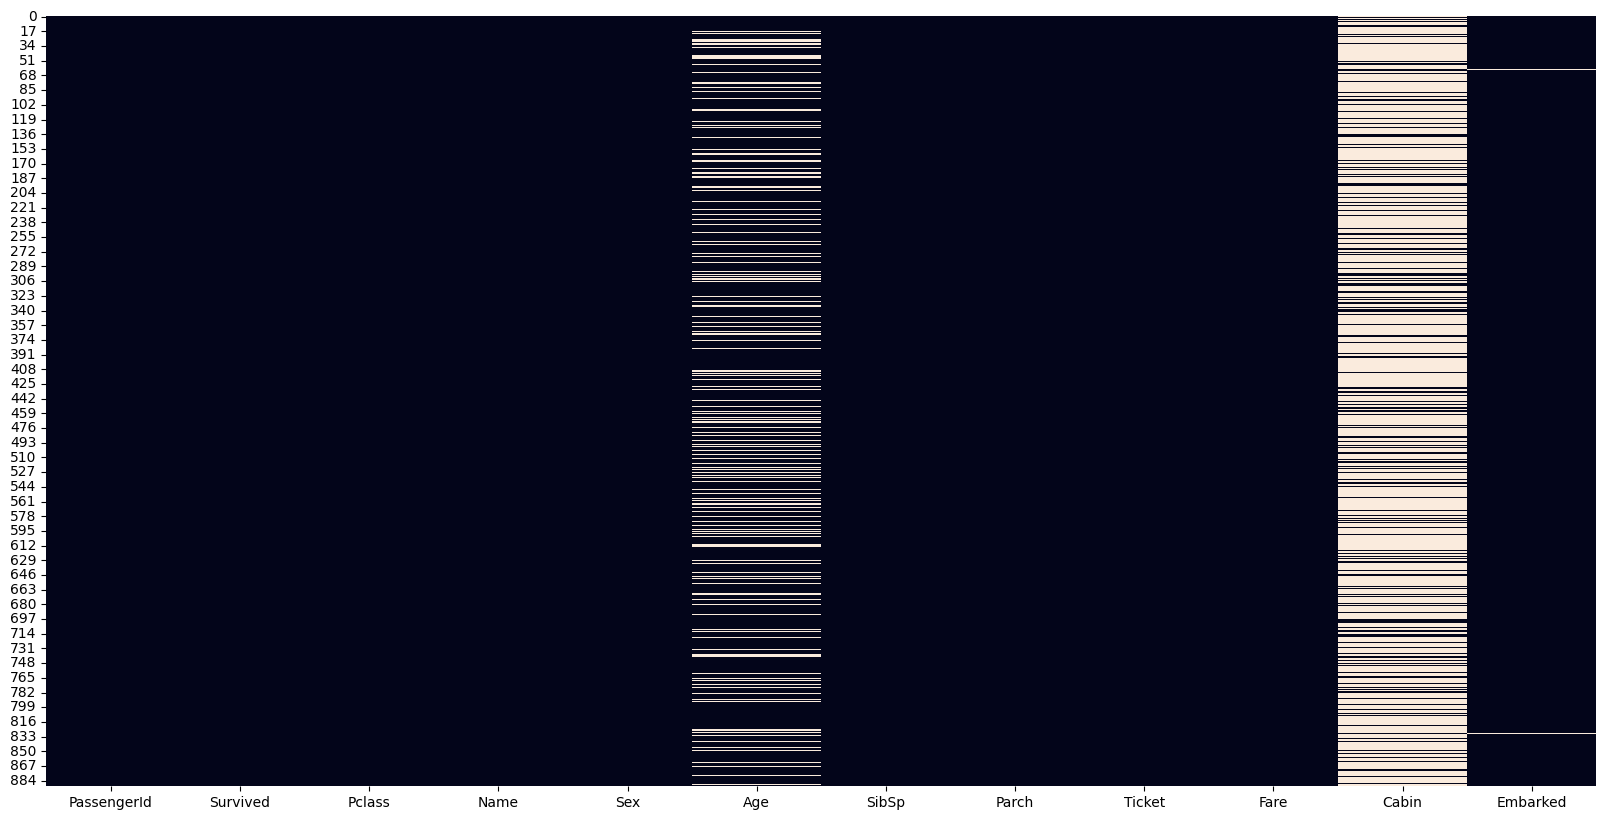

In [313]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(),cbar=False)

In [314]:
manquants_pct = (manquants / len(df) * 100).round(1)  # ccalcul la Calcul du pourcentage de valeurs manquantes
# len(df): nbr de ligne
# round(1):arrondi a 1 chiffre apres virgule

In [315]:
manquants_df = pd.DataFrame({'count': manquants, 'pct': manquants_pct})
# creation d un dataframe resume pour nos dataframe et les valeurs manquantes

In [316]:
print("\nValeurs manquantes :")
print(manquants_df)


Valeurs manquantes :
             count   pct
PassengerId      0   0.0
Survived         0   0.0
Pclass           0   0.0
Name             0   0.0
Sex              0   0.0
Age            177  19.9
SibSp            0   0.0
Parch            0   0.0
Ticket           0   0.0
Fare             0   0.0
Cabin          687  77.1
Embarked         2   0.2


In [317]:
manquants_df = manquants_df[manquants_df['count'] > 0].sort_values('pct', ascending=False)
# On garde seulement les collones qui ont au moin un valeur manquants

In [318]:
print("\nValeurs manquantes :")
print(manquants_df)


Valeurs manquantes :
          count   pct
Cabin       687  77.1
Age         177  19.9
Embarked      2   0.2


Nettoyage

In [319]:
# _______Nettoyage_____
# Dans la colonne age :ramplacons les NaN par la mediane
df['Age'] = df['Age'].fillna(df['Age'].median())

In [320]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [321]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [322]:
#Supprimons les colonnes non necessaire(ou trop de val manquant)
df=df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

In [323]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [324]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [326]:
df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True


visualisation